First of all downloading the data and providing a list of neccessary imports:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
# Loading the dataset
data = pd.read_parquet('green_tripdata_2021-01.parquet')

Data analysis

In [30]:
data.head(20)

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2021-01-01 00:15:56,2021-01-01 00:19:52,N,1.0,43,151,1.0,1.01,5.5,0.5,0.5,0.00,0.0,None,0.3,6.80,2.0,1.0,0.00
1,2,2021-01-01 00:25:59,2021-01-01 00:34:44,N,1.0,166,239,1.0,2.53,10.0,0.5,0.5,2.81,0.0,None,0.3,16.86,1.0,1.0,2.75
2,2,2021-01-01 00:45:57,2021-01-01 00:51:55,N,1.0,41,42,1.0,1.12,6.0,0.5,0.5,1.00,0.0,None,0.3,8.30,1.0,1.0,0.00
3,2,2020-12-31 23:57:51,2021-01-01 00:04:56,N,1.0,168,75,1.0,1.99,8.0,0.5,0.5,0.00,0.0,None,0.3,9.30,2.0,1.0,0.00
4,2,2021-01-01 00:16:36,2021-01-01 00:16:40,N,2.0,265,265,3.0,0.00,-52.0,0.0,-0.5,0.00,0.0,None,-0.3,-52.80,3.0,1.0,0.00
5,2,2021-01-01 00:16:36,2021-01-01 00:16:40,N,2.0,265,265,3.0,0.00,52.0,0.0,0.5,0.00,0.0,None,0.3,52.80,2.0,1.0,0.00
6,2,2021-01-01 00:19:14,2021-01-01 00:19:21,N,5.0,265,265,1.0,0.00,180.0,0.0,0.0,36.06,0.0,None,0.3,216.36,1.0,2.0,0.00
7,2,2021-01-01 00:26:31,2021-01-01 00:28:50,N,1.0,75,75,6.0,0.45,3.5,0.5,0.5,0.96,0.0,None,0.3,5.76,1.0,1.0,0.00
8,2,2021-01-01 00:57:46,2021-01-01 00:57:57,N,1.0,225,225,1.0,0.00,2.5,0.5,0.5,0.00,0.0,None,0.3,3.80,2.0,1.0,0.00
9,2,2021-01-01 00:58:32,2021-01-01 01:32:34,N,1.0,225,265,1.0,12.19,38.0,0.5,0.5,2.75,0.0,None,0.3,42.05,1.0,1.0,0.00


In [ ]:
#Noticed an impossible value in the fare_amount column, which is -52 (4th row). When looking at the data more closely, then the row 5 seems to have the correct values (regarding numerical values the mentioned rows are identical). Hence decided to delelte 4th row. Looking now if there are any more these kinds of impossible values in the data set. 

money_cols = ['fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'total_amount']
print(data[money_cols][data[money_cols] < 0].count())

# Trip duration is 0 seconds or went back in time
print((data['lpep_dropoff_datetime'] <= data['lpep_pickup_datetime']).sum())

# Trip distance is 0 or negative
print((data['trip_distance'] <= 0).sum())

# Passengers 0
print((data['passenger_count'] == 0).sum())

fare_amount     134
extra            46
mta_tax         115
tip_amount       14
tolls_amount      0
total_amount    134
dtype: int64
66
2553
147


In [33]:
data = data.query(
    'fare_amount > 0 and '
    'total_amount > 0 and '
    'mta_tax >= 0 and '
    'extra >= 0 and '
    'tip_amount >= 0 and '
    'trip_distance > 0 and '
    'passenger_count > 0 and '
    'lpep_dropoff_datetime > lpep_pickup_datetime'
)

print(f"Rows after cleaning: {len(data)}")

Rows after cleaning: 73713


In [34]:
# Finding outliers, since this taxi data is known to be asymmetrical, then will use IQR method to find outliers.

def find_outliers_iqr(df, cols):
    for col in cols:
        Q1, Q3 = df[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
        print(f"{col}: {outliers} outliers")

numeric_cols = data.select_dtypes(include='number').columns
find_outliers_iqr(data, numeric_cols)

VendorID: 6064 outliers
RatecodeID: 943 outliers
PULocationID: 0 outliers
DOLocationID: 0 outliers
passenger_count: 3742 outliers
trip_distance: 6457 outliers
fare_amount: 3378 outliers
extra: 15721 outliers
mta_tax: 0 outliers
tip_amount: 867 outliers
tolls_amount: 6569 outliers
improvement_surcharge: 40 outliers
total_amount: 3677 outliers
payment_type: 15221 outliers
trip_type: 764 outliers
congestion_surcharge: 9003 outliers


In [35]:
print(data['extra'].value_counts().head(10))
print(data['trip_distance'].describe())

extra
0.00    45274
2.75    14353
1.00     7315
0.50     5146
5.50      686
3.75      394
3.25      259
1.35      257
4.09       23
4.50        4
Name: count, dtype: int64
count     73713.000000
mean         42.409270
std        1960.665498
min           0.010000
25%           1.400000
50%           2.720000
75%           5.960000
max      244152.010000
Name: trip_distance, dtype: float64


In [41]:
print(data['trip_distance'].describe())

count    73650.000000
mean         4.721955
std          5.225588
min          0.010000
25%          1.400000
50%          2.710000
75%          5.940000
max         95.260000
Name: trip_distance, dtype: float64


In [42]:
data.describe()
data.info()
# Checking for missing values
missing_values = data.isnull().sum()
print(missing_values)


<class 'pandas.DataFrame'>
Index: 73650 entries, 0 to 76517
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               73650 non-null  int64         
 1   lpep_pickup_datetime   73650 non-null  datetime64[us]
 2   lpep_dropoff_datetime  73650 non-null  datetime64[us]
 3   store_and_fwd_flag     73650 non-null  str           
 4   RatecodeID             73650 non-null  float64       
 5   PULocationID           73650 non-null  int64         
 6   DOLocationID           73650 non-null  int64         
 7   passenger_count        73650 non-null  float64       
 8   trip_distance          73650 non-null  float64       
 9   fare_amount            73650 non-null  float64       
 10  extra                  73650 non-null  float64       
 11  mta_tax                73650 non-null  float64       
 12  tip_amount             73650 non-null  float64       
 13  tolls_amount     

From here we can see that we have 76518 trips and 20 variables. From these 20 variables ehail_fee is completely empty. We can also see that 6 variables have the same amount of missing values: store_and_fwd_flag, RatecodeID, passenger_count, payment_type, trip_type, congestion_surcharge.
To see what kind of method to use in order to handle missing values, then looking at the distribution of the missing-value variables next

In [ ]:
sklearn.impute.SimpleImputer(strategy='mean')


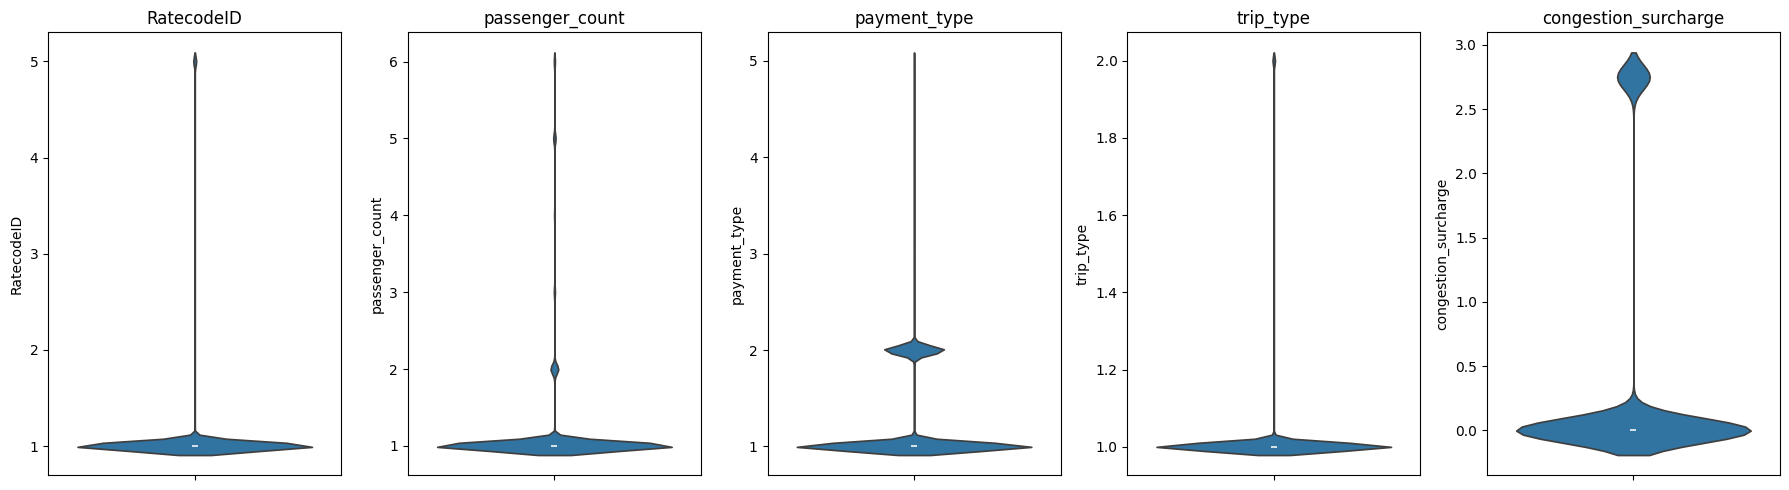

In [43]:
# Visualizing missing values variables
cols = ['RatecodeID', 'passenger_count', 'payment_type', 'trip_type', 'congestion_surcharge']

data_melted = data[cols].melt(var_name='variable', value_name='value')

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, col in enumerate(cols):
    sns.violinplot(y=data[col], ax=axes[i])
    axes[i].set_title(col)
    #if col == 'RatecodeID':
        #axes[i].set_ylim(0, 10)

plt.tight_layout()
plt.show()

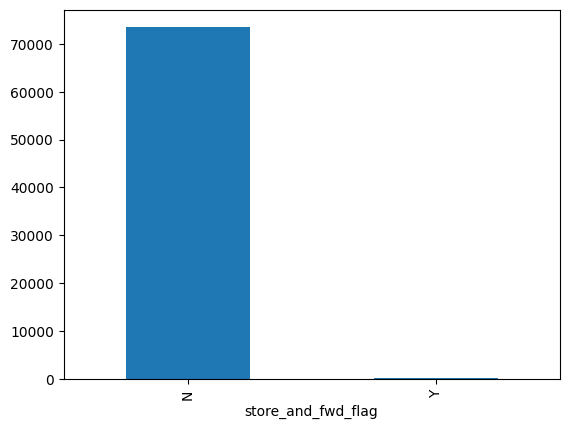

In [44]:
data['store_and_fwd_flag'].value_counts().plot(kind='bar')
plt.show()

From these plots it can be seen the following:
* RatecodeID - almost all the values are around 1, but since there is an outlier at around ~99, then for this median imputation works better for replacing missing values.
* passenger_count - most of the rides are with 1 traveler, and a small part is around 2. For this aswell choosing the median method.
* payment_type - two dominant values (1=credit card, 2=cash), others are rare. For this most_frequent is the best fit.
* trip_type — almost all are 1 (street-hail), very few 2 (dispatch). For this as well most_frequent is the best fit.
* congestion_surcharge — two clear clusters: 0 and 2.75. For this as well most_frequent is the best fit.
* store_and_fwd_flag — two values: N (No, ~40 000) and Y (Yes, ~400), where N dominates with over 98% of records → most_frequent is the best fit.

In [45]:

# Imputing missing values in text column with the most frequent value
text_imputer = SimpleImputer(strategy='most_frequent')
data['store_and_fwd_flag'] = text_imputer.fit_transform(data[['store_and_fwd_flag']]).ravel()

print(data['store_and_fwd_flag'].isnull().sum())
print(data['store_and_fwd_flag'].value_counts())

0
store_and_fwd_flag
N    73438
Y      212
Name: count, dtype: int64


In [46]:
# Imputing missing values in numerical columns

# Median imputation - skewed distribution or outliers present
median_imputer = SimpleImputer(strategy='median')
median_cols = ['RatecodeID', 'passenger_count']
data[median_cols] = median_imputer.fit_transform(data[median_cols])

# Most frequent imputation - categorical or dominant value distribution
freq_imputer = SimpleImputer(strategy='most_frequent')
freq_cols = ['payment_type', 'trip_type', 'congestion_surcharge']
data[freq_cols] = freq_imputer.fit_transform(data[freq_cols])

print(data[median_cols + freq_cols].isnull().sum())

RatecodeID              0
passenger_count         0
payment_type            0
trip_type               0
congestion_surcharge    0
dtype: int64


Feature engineering so that the model would have better accuracy (hopefully)

In [55]:
# Creating new features
data['hour'] = data['lpep_pickup_datetime'].dt.hour
data['day_of_week'] = data['lpep_pickup_datetime'].dt.dayofweek
data['is_weekend'] = data['day_of_week'].isin([5, 6]).astype(int)

In [56]:
#  The variable chosen for regression task is trip_duration, since it is a continuous variable and has a wide range of values, which makes it suitable for regression analysis. Additionally, understanding the factors that influence trip duration can provide valuable insights for optimizing taxi services and improving customer experience.
data['trip_duration'] = (data['lpep_dropoff_datetime'] - data['lpep_pickup_datetime']).dt.total_seconds() / 60

In [57]:
# Creating a new variable to indicate if a tip was given - this is for classification task, where we want to predict if a tip was given or not. 
data['tip_given'] = (data['tip_amount'] > 0).astype(int)
data['tip_given'].value_counts()

tip_given
1    40157
0    33493
Name: count, dtype: int64

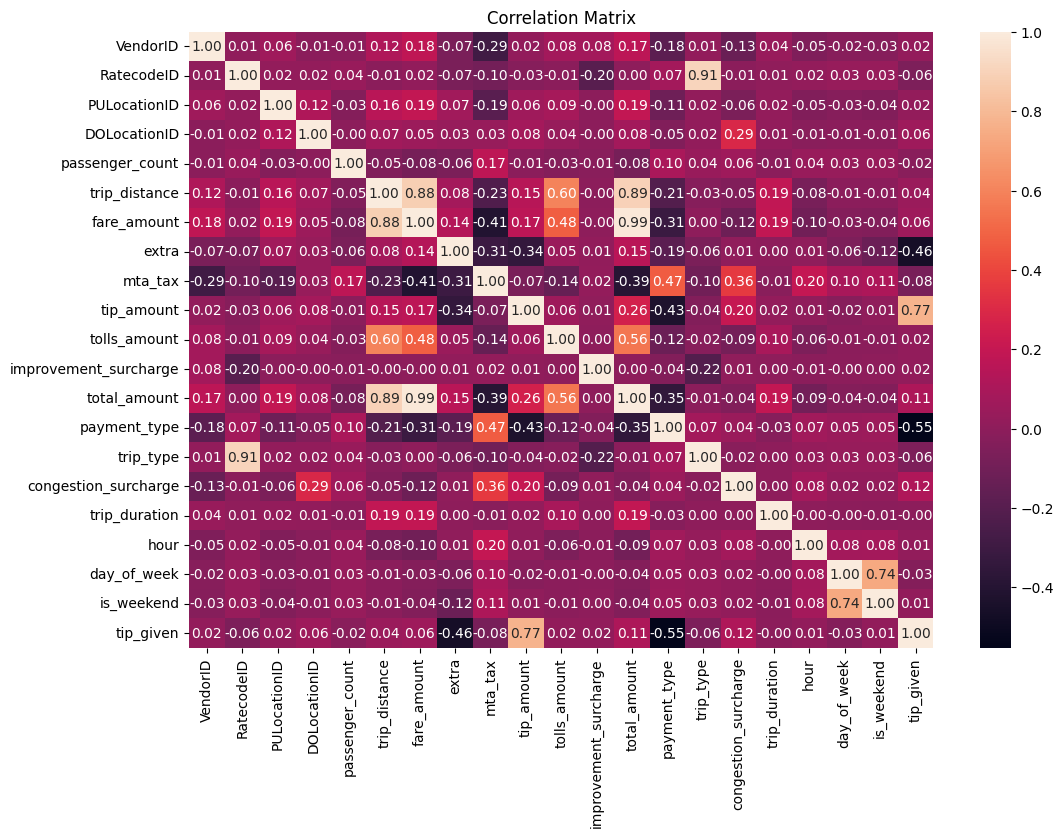

In [66]:
# Correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True, fmt='.2f', cmap='rocket')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# Dropping unnecessary columns - datetime columns already used for feature engineering, ehail_fee is entirely empty
cols_to_drop = ['lpep_pickup_datetime', 'lpep_dropoff_datetime', 'ehail_fee']
data = data.drop(columns=cols_to_drop)
print(data.columns.tolist())

['VendorID', 'store_and_fwd_flag', 'RatecodeID', 'PULocationID', 'DOLocationID', 'passenger_count', 'trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'payment_type', 'trip_type', 'congestion_surcharge', 'trip_duration', 'hour', 'day_of_week', 'is_weekend', 'tip_given']


In [71]:
# Encoding categorical column
data['store_and_fwd_flag'] = (data['store_and_fwd_flag'] == 'Y').astype(int)

ML modelling

In [85]:
# Regression - predicting trip duration
X_reg = data.drop(columns=['fare_amount', 'tip_given', 'tip_amount', 'total_amount']) # Dropping fare_amount (data leakage - directly related to trip duration), tip_given (classification target, not relevant here), tip_amount (data leakage - only known after the trip is completed) and total_amount (data leakage - directly related to trip duration).
y_reg = data['fare_amount']

# Classification - predicting whether tip was given
X_clf = data.drop(columns=['tip_given', 'tip_amount']) # Dropping tip_given (target variable) and tip_amount (data leakage - directly used to create tip_given)
y_clf = data['tip_given']

In [84]:
# Top correlations with fare_amount
print(data.corr(numeric_only=True)['fare_amount'].sort_values(ascending=False))

fare_amount              1.000000
total_amount             0.986923
trip_distance            0.879927
tolls_amount             0.476569
trip_duration            0.189959
PULocationID             0.189358
VendorID                 0.176210
tip_amount               0.167545
extra                    0.136994
tip_given                0.055896
DOLocationID             0.049803
RatecodeID               0.015953
trip_type                0.001979
improvement_surcharge   -0.000230
store_and_fwd_flag      -0.028084
day_of_week             -0.033381
is_weekend              -0.039209
passenger_count         -0.083716
hour                    -0.102341
congestion_surcharge    -0.118999
payment_type            -0.309610
mta_tax                 -0.411277
Name: fare_amount, dtype: float64


In [76]:
# Top correlations with tip_given
print(data.corr(numeric_only=True)['tip_given'].sort_values(ascending=False))

tip_given                1.000000
tip_amount               0.771704
congestion_surcharge     0.118475
total_amount             0.110815
fare_amount              0.055896
DOLocationID             0.055730
trip_distance            0.044457
VendorID                 0.020667
PULocationID             0.019912
tolls_amount             0.017422
improvement_surcharge    0.017332
hour                     0.014877
is_weekend               0.012491
trip_duration           -0.003731
store_and_fwd_flag      -0.009462
passenger_count         -0.017938
day_of_week             -0.033287
RatecodeID              -0.058016
trip_type               -0.060973
mta_tax                 -0.078100
extra                   -0.461286
payment_type            -0.552108
Name: tip_given, dtype: float64


In [86]:
# Feature selection
reg_features = ['trip_distance', 'trip_duration', 'tolls_amount']
clf_features = ['payment_type', 'extra', 'congestion_surcharge']

X_reg_selected = X_reg[reg_features]
X_clf_selected = X_clf[clf_features]

# Train/test split
from sklearn.model_selection import train_test_split

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg_selected, y_reg, test_size=0.2, random_state=42)
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(X_clf_selected, y_clf, test_size=0.2, random_state=42)

In [ ]:
# Scaling - logistic regression needs it
scaler = StandardScaler()
X_clf_train_scaled = scaler.fit_transform(X_clf_train)
X_clf_test_scaled = scaler.transform(X_clf_test)

# Regression - Random Forest
reg_model = RandomForestRegressor(n_estimators=10, random_state=42)
reg_model.fit(X_reg_train, y_reg_train)

y_reg_pred = reg_model.predict(X_reg_test)

print("Random Forest Regression")
print(f"MAE: {mean_absolute_error(y_reg_test, y_reg_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_reg_test, y_reg_pred)):.2f}")
print(f"R2 Score: {r2_score(y_reg_test, y_reg_pred):.2f}")


Random Forest Regression
MAE: 2.94
RMSE: 5.77
R2 Score: 0.84


In [80]:
# Classification - Logistic Regression
clf_model = LogisticRegression(random_state=42)
clf_model.fit(X_clf_train_scaled, y_clf_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [82]:
# Classification evaluation
y_clf_pred = clf_model.predict(X_clf_test_scaled)

print("Logistic Regression Classification")
print(f"Accuracy: {accuracy_score(y_clf_test, y_clf_pred):.2f}")
print(classification_report(y_clf_test, y_clf_pred))

Logistic Regression Classification
Accuracy: 0.93
              precision    recall  f1-score   support

           0       0.97      0.86      0.92      6764
           1       0.90      0.98      0.94      7966

    accuracy                           0.93     14730
   macro avg       0.93      0.92      0.93     14730
weighted avg       0.93      0.93      0.93     14730



In [ ]:
#Saving the models using joblib
joblib.dump(reg_model, 'random_forest_regression.pkl')
joblib.dump(clf_model, 'logistic_regression_classification.pkl')

print("Models saved successfully!")

Models saved successfully!
